<span style="color:gray; font-size:smaller;">Written by Chang Yun</span>

# Tutorial 5 - Annotating motifs

**Problem**: Now that we have many motifs, and some cluster aggregations of the motifs (that can be viewed as the 'non-redundant set'), next, we want to **know what they are!** 

In other words... **What even are these things..?**

**Solution**: Here, we attempt to **annotate the motifs** (i.e., name them!)

**Approach**: The general approach to this step is as follows:
- **Step 1**: Find a well-trusted **reference motif database** to use as a ground truth for names.
- **Step 2**: **Compare** our MotifCompendium with the reference motifs, based on our similarity score:
    - High score: Good match 👍
    - Low score: Poor match 👎
- **Step 3**: For each one of our motifs, find the **corresponding, best matching reference motif** (by highest similarity score, above a certain threshold). Assign the name (and logos) of the matched reference motif to our motif
- (Optional) **Step 4**: Annotate with ***other* MotifCompendium objects** 
- (Optional) **Step 5**: Identify **composite motifs**

Et voila! We have **annotated our motifs**! (using the same base MotifCompendium engine)

## Part 1 - Find a (good) reference motif database

To start off, we need a good, well-trusted **reference motif database**. This is because, in practice, annotating motifs from scratch is *hard*. There are assays specifically designed for this task that target one protein (e.g., *in vivo*: TF ChIP-seq; *in vitro*: PBM, SELEX), and even then, we need expert guidance before trusting them right away (e.g., ChIP-seq: Off-target, protein-protein cooperativity; PBM: non-*in vivo* effects).

Fortunately, we have help to the rescue! There are many curated reference motif databases that are publicly-available. Two popular examples are: 
- (1) **JASPAR**: An open-access, manually curated database of transcription factor (TF) binding profiles in **six eurkaryotic taxonomic groups**: Vertebrata, Insecta, Plantae, Fungi, Nematoda, Urochordata
- (2) **HOCOMOCO** (HOmo sapiens COmprehensive MOdel COllection): An open-access, curated database of **human and mouse** transcription factor binding profiles

As a starting point, we have pre-compiled **two human TF binding motifs** within the repo at: `./pipeline/data`. 
1. `MotifCompendium-Database-Human.meme.txt`: A motif-centric database (assembled using MotifCompendium), that shows all possible TFs that bind for each major motif type, assembled from:
    - (1) **JASPAR**: Version 2024, CORE, Homo sapiens only (https://jaspar.elixir.no/collection/core/)
    - (2) **HOCOMOCO**: V13, CORE, Human only (https://hocomoco13.autosome.org/H13CORE)
    - (3) **Codebook**: MEX Top 1 (https://mex.autosome.org/approved)
    - (4) **CAP-SELEX, Taipale**: Taipale, 2024
    - (5) **CIS-BP**: V3, Human
2. `HUMAN-JASPAR2024-HOCOMOCOv13.meme.txt`: A simple combination of two databases:
    - (1) **JASPAR**: Version 2024, CORE, Homo sapiens only (https://jaspar.elixir.no/collection/core/)
    - (2) **HOCOMOCO**: V13, CORE, Human only (https://hocomoco13.autosome.org/H13CORE)

In [1]:
# Finding the default reference motif database
reference_meme = '../pipeline/data/MotifCompendium-Database-Human.meme.txt'

## Part 2 - Compare our MotifCompendium vs. Reference

Next, we need to compare **our MotifCompendium vs. the reference database**, to find the best annotation for each motif. 

To do this, we need to compare all our MotifCompendium motifs (N motifs) vs. all the reference database motifs (M motifs). This becomes N x M pairs of comparisons (times length (2L-1), times reverse complement (2))... So many calculations... What do we do? 

**We use our trusted MotifCompendium engine!** Using the same base MotifCompendium engine, we can calculate the max similarity score between all N x M pairs of motifs. And then for each of our N motifs, we can select the best match.

All of this is done under the hood in one function: `MotifCompendium.utils.analysis.assign_label_from_pfms()` - let's look at how this works:

In [2]:
# Standard MotifCompendium setup
import os
import numpy as np
import pandas as pd
from IPython.display import Image, display
import base64
import gdown

import MotifCompendium

# Set compute options
max_chunk = 800
max_cpus = 16
use_gpu = True
safe = True
fast_plot = False

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
MotifCompendium.set_compute_options(
    max_chunk=max_chunk,
    max_cpus=max_cpus,
    use_gpu=use_gpu,
    fast_plotting=fast_plot,
)

In [3]:
# Download test MotifCompendium object from Google Drive
file_id = "1XQ7pWbEeP2RKEg5d5jJ1JOjotXXPFaeL"
file_url = f'https://drive.google.com/uc?id={file_id}'
output_path = "tutorial_data/tutorial_motif_compendium.mc"

gdown.download(file_url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1XQ7pWbEeP2RKEg5d5jJ1JOjotXXPFaeL
To: /oak/stanford/groups/akundaje/cmyun/software/motifcompendium/tutorials/tutorial_data/tutorial_motif_compendium.mc
100%|██████████| 1.30M/1.30M [00:00<00:00, 45.6MB/s]


'tutorial_data/tutorial_motif_compendium.mc'

In [4]:
# Load MotifCompendium object
mc = MotifCompendium.load(output_path, safe=safe)

In [5]:
# View MotifCompendium object
mc

,name,num_seqlets,model,posneg,avg_dist_from_summit,cluster,annotation
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,15.721553,0,CTCF#1_0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,33.662853,8,NFI#1_8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,33.419699,11,HD:MEIS-TGIF_11
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,36.965818,12,GATA#1_12
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,42.597554,13,ETS:ELF-ETV#1_13
...,...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,37.803475,9,BZIP:FOSL-JUND#1_9
84,endothelial-pos.pattern_6,2977,endothelial,pos,35.074236,10,NFY_10
85,endothelial-pos.pattern_7,2358,endothelial,pos,37.488550,4,BZIP:ATF-CREB#1_4
86,endothelial-pos.pattern_8,2115,endothelial,pos,51.907329,76,ETS:ELF-SPIB#1_76


We use the one function `MotifCompendium.utils.analysis.assign_label_from_pfms()` to do best matching with a database (in PFM or MEME txt format). Some arguments that we can specify:
- `mc`: Target MotifCompendium object to annotate
- `pfm_file`: Path to the reference motif database (in PFM or MEME txt format)
- `save_col_prefix`: The best matching annotation will be stored in metadata (and images, for logos; *default: `'match'`*). The newly added columns will follow the name:
    - `{save_col_prefix}_score0`: Highest similarity score with any motif from the reference database
    - `{save_col_prefix}_name0`: Name of the reference database motif, that matched with the highest similarity score
    - (If `save_images` is `True`): `{save_col_prefix}_logo0`: Image data of the matched reference database motif
- `ic`: Whether or not to perform information content scaling on the motifs. Options:
    - `True`, the motifs will be scaled to have a maximum information content of 1. 
    - `False`, the motifs will not be scaled.
- `min_score`: Minimum similarity score to be considered a match *(default: 0.5; suggested: ~0.7)*
- `save_images`: Whether or not to save reference database motif images *(default: `True`)* Logo saved under image column
- `logo_trimming`: (If `save_images` is `True`) A bool or number indicating how much the motifs should be trimmed. Options:
    - `True`: Trim flanks with contribution less than 1/L * max contribution
    - `False`: No trimming
    - `[0, 1]`: Trim flanks below select proportion * max contribution (where, 0: Trim only zeros, 1: Trim all positions)

In [6]:
# Label MotifCompendium motifs with reference database
import MotifCompendium.utils.analysis as utils_analysis

annotation_col = 'annotation_database'
min_score = 0.7
save_images = True

utils_analysis.assign_label_from_pfms(
    mc=mc,
    pfm_file=reference_meme,
    ic=False,
    save_col_prefix=annotation_col,
    min_score=min_score,
    save_images=save_images,
    logo_trimming=0,
)

## Part 3 - Assign annotation name (and logos)

Let's see how it matched!

In [7]:
# View MotifCompendium object
mc.metadata[["name", f"{annotation_col}_name0", f"{annotation_col}_score0"]]

,name,annotation_database_name0,annotation_database_score0
0,cardiomyocyte-pos.pattern_0,"CTCF,CTCFL",0.980312
1,cardiomyocyte-pos.pattern_1,"NFIB,NFIC,NFIX",0.896397
2,cardiomyocyte-pos.pattern_10,"NKX25,TBX20,TBX5",0.920984
3,cardiomyocyte-pos.pattern_11,"GATA1,GATA2,GATA3,GATA4,GATA5,GATA6,GATAD2A,TA...",0.967001
4,cardiomyocyte-pos.pattern_12,"EHF,ELF1,ELF2,ELF3,ELF4,ELF5,ELK1,ELK3,ELK4,ER...",0.904430
...,...,...,...
83,endothelial-pos.pattern_5,"ATF3,BACH1,BACH2,BATF,BATF3,BNC2,FOS,FOSB,FOSL...",0.987846
84,endothelial-pos.pattern_6,"NFYA,NFYB,NFYC,PBX1,PBX2,PBX3,PKNX1,ZNF516",0.968724
85,endothelial-pos.pattern_7,"CREB3L3,CXXC4,GMEB1,GMEB2,HIF1A,SP140L,TET3,XBP1",0.929561
86,endothelial-pos.pattern_8,ZNF813,0.856285


In [8]:
# Visualize logos
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", True)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", True)

Target MC motif: endothelial-pos.pattern_5


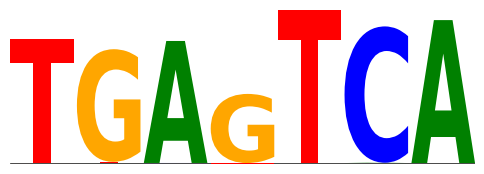

Matched database motif: ATF3,BACH1,BACH2,BATF,BATF3,BNC2,FOS,FOSB,FOSL1,FOSL2,JDP2,JUN,JUNB,JUND,MAFK,NFE2


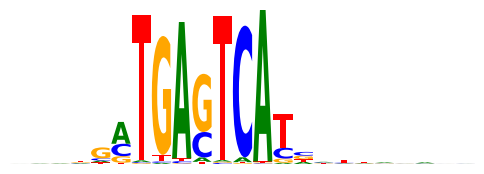

In [9]:
# View example of a matched motif
mc.sort(by=f"{annotation_col}_score0", ascending=False, inplace=True)

logo = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo[0])
print(f"Target MC motif: {mc.metadata['name'][0]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo0")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched database motif: {mc.metadata[f'{annotation_col}_name0'][0]}")
display(Image(data=image_bytes, format='png'))

**That's it!** Now we can **annotate our motifs** in reference to a known motif database! 🎉

## Part 4 - (Optional) Annotate with *other* MotifCompendia

Given that 'annotation' is just a N x M comparison with another set of motifs, we can ask the question: ***Why can't we just compare two MotifCompendia?***

The answer is: **Yes, we can!**

Similar to annotating with a reference motif database (in PFM or MEME txt format), we can also **'annotate' with another MotifCompendium object**, using a function: `MotifCompendium.assign_label_from_other()` with similar arguments:
- `assign_to_mc`: Target MotifCompendium to assign labels to
- `assign_from_mc`: The reference MotifCompendium to use labels from
- `from_label_col`: The "name" of the other MotifCompendium's motifs to use for annotation *(default: `'name'`)*
- `save_col_prefix`: The best matching annotation will be stored in metadata (and images, for logos; *default: `'match'`*). The newly added columns will follow the name:
    - `{save_col_prefix}_score0`: Highest similarity score with any motif from the reference database
    - `{save_col_prefix}_name0`: Name of the reference database motif, that matched with the highest similarity score
    - (If `save_images` is `True`): `{save_col_prefix}_logo0`: Image data of the matched reference database motif
- `min_score`: Minimum similarity score to be considered a match *(default: 0.5; suggested: ~0.7)*
- `save_images`: Whether or not to save reference database motif images *(default: `True`)* Logo saved under image column
- `logo_trimming`: (If `save_images` is `True`) A bool or number indicating how much the motifs should be trimmed. Options:
    - `True`: Trim flanks with contribution less than 1/L * max contribution
    - `False`: No trimming
    - `[0, 1]`: Trim flanks below select proportion * max contribution (where, 0: Trim only zeros, 1: Trim all positions)

In [10]:
# Download a second MotifCompendium object from Google Drive
file_id = "1zDPVexneyg1mTY5L35bPL2GHuRfDuIjF"
file_url = f'https://drive.google.com/uc?id={file_id}'
output_path = "tutorial_data/8_motifcompendium.mc"

gdown.download(file_url, output_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1zDPVexneyg1mTY5L35bPL2GHuRfDuIjF
To: /oak/stanford/groups/akundaje/cmyun/software/motifcompendium/tutorials/tutorial_data/8_motifcompendium.mc
100%|██████████| 1.26M/1.26M [00:00<00:00, 43.1MB/s]


'tutorial_data/8_motifcompendium.mc'

In [11]:
# Load MotifCompendium object
mc_2 = MotifCompendium.load(output_path, safe=safe)

In [12]:
# View MotifCompendium object
mc_2

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit
0,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,8484,ENCSR155NPL,pos,1.144705,53.913013
1,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,3749,ENCSR155NPL,pos,0.442782,62.320085
2,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,1290,ENCSR155NPL,pos,0.591501,62.542636
3,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,1242,ENCSR155NPL,pos,0.516817,54.874396
4,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,1128,ENCSR155NPL,pos,0.461878,61.909574
...,...,...,...,...,...,...
70,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,1924,ENCSR279SXQ,pos,0.939136,61.019751
71,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,1366,ENCSR279SXQ,pos,0.683914,55.295022
72,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,1199,ENCSR279SXQ,pos,0.727986,69.727273
73,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,606,ENCSR279SXQ,pos,0.650236,54.107261


In [13]:
# Label MotifCompendium motifs with another MotifCompendium object
from_label_col = 'name'
annotation_col = 'annotation_mc2'
min_score = 0.7
save_images = True

utils_analysis.assign_label_from_other_compendium(
    assign_to_mc=mc,
    assign_from_mc=mc_2,
    from_label_col=from_label_col,
    save_col_prefix=annotation_col,
    min_score=min_score,
    save_images=save_images,
    logo_trimming=True,
)

Let's see how it matched again!

In [14]:
# View MotifCompendium object
mc.metadata[["name", f"{annotation_col}_name0", f"{annotation_col}_score0"]]

,name,annotation_mc2_name0,annotation_mc2_score0
0,endothelial-pos.pattern_5,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,0.994716
1,endothelial-pos.pattern_1,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.994285
2,endothelial-pos.pattern_4,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,0.765934
3,cardiomyocyte-pos.pattern_0,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.996361
4,endothelial-pos.pattern_13,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.866003
...,...,...,...
83,cardiomyocyte-pos.pattern_28,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.867206
84,cardiomyocyte-pos.pattern_39,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,0.870199
85,endothelial-pos.pattern_39,,0.000000
86,cardiomyocyte-pos.pattern_34,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.715868


In [15]:
# Visualize logos
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", True)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", True)

Target MC motif: cardiomyocyte-pos.pattern_7


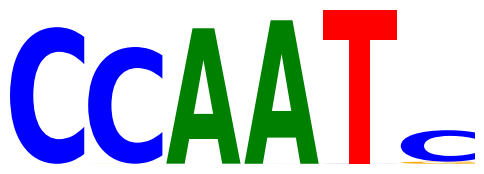

Matched other MC motif: ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_ENCFF996DFY_counts_pattern_3


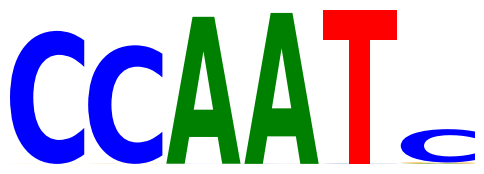

In [16]:
# View example of a matched motif
mc.sort(by=f"{annotation_col}_score0", ascending=False, inplace=True)

logo = mc.get_images('logo (rev)')
image_bytes = base64.b64decode(logo[0])
print(f"Target MC motif: {mc.metadata['name'][0]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo0")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched other MC motif: {mc.metadata[f'{annotation_col}_name0'][0]}")
display(Image(data=image_bytes, format='png'))

Now, we can compare and annotate our motifs **with another MotifCompendium object**! 🎉

## Part 5 -  (Optional) Identify composite motifs

Transcription factors (TF) typically **do not act alone**. They engage in cooperative interaction, sometimes even with other TFs. And even if TFs are not interacting together, they may just be sitting next to each other (by chance).

Either way, we might call these **"composite motifs"** - a combination of ***two or more motifs***.

These are particularly interesting as they can highlight **more complex information**, than just one TF binding at one site. And so, we would love to be able to identify and annotate them. 

Fortunately, we can use MotifCompendium to **identify composite motifs**!

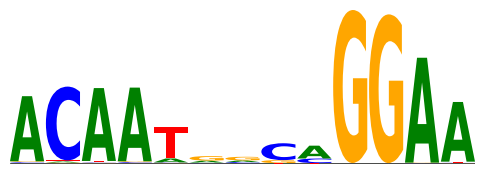

In [17]:
# Example of a composite motif: Two motifs along side each other
example_composite = "endothelial-pos.pattern_11"

idx = mc.metadata.index[mc['name'] == example_composite][0]
logo_fwd = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo_fwd[idx])
display(Image(data=image_bytes))

In MotifCompendium, we do this by **annotating a motif over multiple rounds**. This is done by specifying the argument: `max_submotifs`, in both `MotifCompendium.utils.analysis.assign_label_from_pfms()` and `MotifCompendium.assign_label_from_other()`:
- `max_submotifs`: The maximum number of submotifs to consider during annotation *(default: 1)*
    - This increases the counter of all `save_col_prefix` columns, from `i=0, ..., max_submotifs-1` *(default: `i=0`)*
    - `{save_col_prefix}_score{i}`: Highest similarity score with any motif from the reference database
    - `{save_col_prefix}_name{i}`: Name of the reference database motif, that matched with the highest similarity score
    - (If `save_images` is `True`): `{save_col_prefix}_logo{i}`: Image data of the matched reference database motif

Let's re-run `MotifCompendium.utils.analysis.assign_label_from_pfms()` with `max_submotifs=2`:

In [18]:
# Label MotifCompendium motifs with reference database
import MotifCompendium.utils.analysis as utils_analysis

annotation_col = 'annotation_database'
min_score = 0.7
max_submotifs = 2
save_images = True

utils_analysis.assign_label_from_pfms(
    mc=mc,
    pfm_file=reference_meme,
    save_col_prefix=annotation_col,
    min_score=min_score,
    max_submotifs=max_submotifs,
    save_images=save_images,
    logo_trimming=0,
)

In [19]:
# View MotifCompendium object
mc

,name,num_seqlets,model,posneg,avg_dist_from_summit,cluster,annotation,annotation_database_score0,annotation_database_name0,annotation_mc2_score0,annotation_mc2_name0,annotation_database_score1,annotation_database_name1
0,cardiomyocyte-pos.pattern_7,5180,cardiomyocyte,pos,40.583591,10,NFY_10,0.967620,"NFYA,NFYB,NFYC,PBX1,PBX2,PBX3,PKNX1,ZNF516",0.998887,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,0.0,
1,endothelial-pos.pattern_6,2977,endothelial,pos,35.074236,10,NFY_10,0.968724,"NFYA,NFYB,NFYC,PBX1,PBX2,PBX3,PKNX1,ZNF516",0.998732,ENCSR279SXQ-pos.ENCSR279SXQ_DNASE_left-colon_E...,0.0,
2,endothelial-pos.pattern_3,5844,endothelial,pos,41.685147,8,NFI#1_8,0.912355,"NFIB,NFIC,NFIX",0.997471,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.0,
3,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,42.597554,13,ETS:ELF-ETV#1_13,0.904430,"EHF,ELF1,ELF2,ELF3,ELF4,ELF5,ELK1,ELK3,ELK4,ER...",0.996764,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.0,
4,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,15.721553,0,CTCF#1_0,0.980312,"CTCF,CTCFL",0.996361,ENCSR155NPL-pos.ENCSR155NPL_DNASE_renal-cortex...,0.0,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,cardiomyocyte-pos.pattern_22,713,cardiomyocyte,pos,32.892006,20,HD:MEIS-TGIF_20,0.861358,"HAND1,HAND2",0.000000,,0.0,
84,cardiomyocyte-pos.pattern_40,27,cardiomyocyte,pos,29.444444,39,HD:MEIS-TGIF_39,0.872759,"MEIS1,MEIS2,MEIS3,PBX1,PBX2,PKNX1,PKNX2,TF2LX,...",0.000000,,0.0,
85,cardiomyocyte-pos.pattern_26,295,cardiomyocyte,pos,33.125424,23,Unknown_23,0.845778,"NFIA,NFIB,NFIC,NFIX",0.000000,,0.0,
86,cardiomyocyte-pos.pattern_38,54,cardiomyocyte,pos,44.092593,36,Unknown_36,0.871196,"ANDR,AR,GCR,MCR,NR3C1,NR3C2,PRGR",0.000000,,0.0,


Now, most motifs will be single, non-composite motifs. One way to easily check for any composite motifs is checking that there are any matches in the columns `i > 0`:

In [20]:
# Check if any composite motifs
print(f"Number of composite motifs: {(mc[f'{annotation_col}_score1'] > 0).sum()}")

Number of composite motifs: 2


Looks like we have **2 x potential composite motifs**! Let's see what they look like:

In [21]:
# Visualize logos
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", True)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", True)

Target MC motif: endothelial-pos.pattern_28


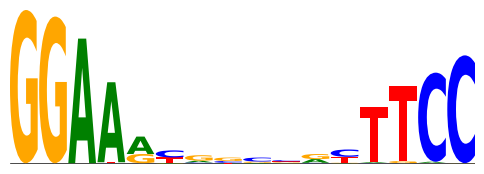

Matched database motif (first): ETV7,NFAC1,NFAC2,NFAC3,NFAC4,NFAT5,NFATC2,NFATC3,NFATC4,SPI1,SPIB


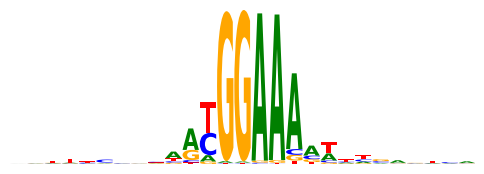

Matched database motif (second): ETV7,NFAC1,NFAC2,NFAC3,NFAC4,NFAT5,NFATC2,NFATC3,NFATC4,SPI1,SPIB


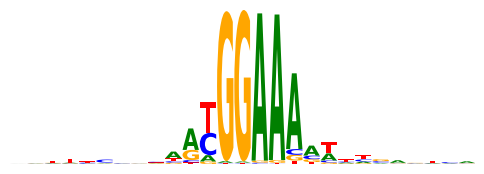

In [22]:
# View example of a matched motif
mc.sort(by=f"{annotation_col}_score1", ascending=False, inplace=True)

logo = mc.get_images('logo (fwd)')
image_bytes = base64.b64decode(logo[0])
print(f"Target MC motif: {mc.metadata['name'][0]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo0")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched database motif (first): {mc.metadata[f'{annotation_col}_name0'][0]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo1")
image_bytes = base64.b64decode(match_fwd[0])
print(f"Matched database motif (second): {mc.metadata[f'{annotation_col}_name1'][0]}")
display(Image(data=image_bytes, format='png'))

It seems like one is a **homodimer of 2 x NFA family motifs**...

Target MC motif: endothelial-pos.pattern_11


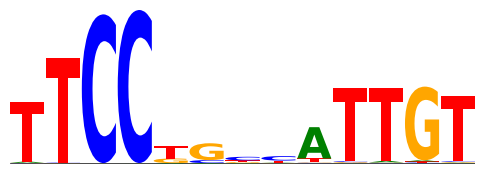

Matched database motif (first): ETS1,HINFP,ZN441


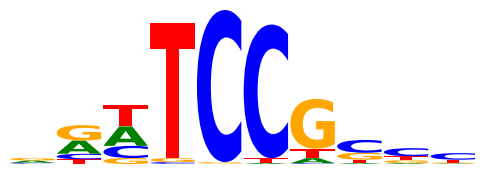

Matched database motif (second): SOX10,SOX11,SOX12,SOX13,SOX14,SOX15,SOX17,SOX18,SOX2,SOX3,SOX30,SOX4,SOX5,SOX6,SOX7,SOX8,SOX9,SRY


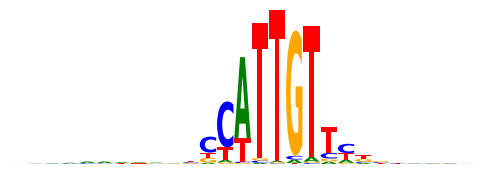

In [23]:
# View example of a matched motif
logo = mc.get_images('logo (rev)')
image_bytes = base64.b64decode(logo[1])
print(f"Target MC motif: {mc.metadata['name'][1]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo0")
image_bytes = base64.b64decode(match_fwd[1])
print(f"Matched database motif (first): {mc.metadata[f'{annotation_col}_name0'][1]}")
display(Image(data=image_bytes, format='png'))

match_fwd = mc.get_images(f"{annotation_col}_logo1")
image_bytes = base64.b64decode(match_fwd[1])
print(f"Matched database motif (second): {mc.metadata[f'{annotation_col}_name1'][1]}")
display(Image(data=image_bytes, format='png'))

And the other is a **heterodimer of ~ETS/HINFP + SOX**!

Now, we can **identify potential composite motifs**, based on a reference motif database! 🎉